## Fonctions pour afficher les champs de vitesse de vent et les infra rouges , 

In [1]:
import os 
os.chdir("/scale/user/mtannaou/alternance")
from src.visualisation.utils_colormap import CMAP
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

cmap_ir = CMAP.cira_ir()
cmap_sar = CMAP.cmap_sar()

def plot_sar(tensor, fig=None, ax=None, cmap=cmap_sar, title=None,
             x_lim=300, x=None, y=None):

    if ax is None:
        ax = plt.gca()

    if x is None:
        y_sar = np.linspace(-x_lim, x_lim, tensor.shape[0])
        x_sar = np.linspace(-x_lim, x_lim, tensor.shape[1])
        x_sar, y_sar = np.meshgrid(x_sar, y_sar)
    else:
        x_sar, y_sar = x, y   # déjà 2D, pas de meshgrid

    im = ax.pcolormesh(
        x_sar,
        y_sar,
        tensor,
        cmap=cmap,
        vmin=0,
        vmax=160/1.94384449,
        shading="auto"
    )

    if x is None:
        ax.set_xlim(-x_lim, x_lim)
        ax.set_ylim(-x_lim, x_lim)

    if title is not None:
        ax.set_title(title)

    if fig is not None:
        fig.colorbar(im, ax=ax, orientation="horizontal")

    ax.set_aspect("equal")


def plot_ir(tensor, fig=None, x=None, y=None, ax=None, x_lim=300,
            cmap=cmap_ir, vmin=-100, vmax=50):

    if ax is None:
        ax = plt.gca()

    tensor = np.squeeze(tensor)
    ny, nx = tensor.shape  # ny = rows, nx = cols

    if x is None:
        x = np.linspace(-x_lim, x_lim, nx)

    if y is None:
        y = np.linspace(-x_lim, x_lim, ny)

    im = ax.pcolormesh(
        x, y, tensor,
        cmap=cmap,
        shading="nearest",
        vmin=vmin,
        vmax=vmax
    )

    if x is None or y is None:
        ax.set_xlim(-x_lim, x_lim)
        ax.set_ylim(-x_lim, x_lim)
    else:
        ax.set_xlim(np.min(x), np.max(x))
        ax.set_ylim(np.min(y), np.max(y))
    ax.set_aspect("equal")

    if fig is not None:
        fig.colorbar(im, ax=ax, orientation="horizontal")

def compute_metrics(
    observations,
    predictions,
):
    observations = np.asarray(
        observations,
        dtype=np.float64,
    )

    predictions = np.asarray(
        predictions,
        dtype=np.float64,
    )

    valid = (
        np.isfinite(observations)
        &
        np.isfinite(predictions)
    )

    if valid.sum() == 0:
        return {
            "n": 0,
            "rmse": np.nan,
            "mae": np.nan,
            "bias": np.nan,
            "correlation": np.nan,
        }

    obs = observations[valid]
    pred = predictions[valid]

    rmse = np.sqrt(
        np.mean(
            (pred - obs) ** 2
        )
    )

    mae = np.mean(
        np.abs(pred - obs)
    )

    bias = np.mean(
        pred - obs
    )

    if len(obs) >= 2:
        correlation = np.corrcoef(
            obs,
            pred,
        )[0, 1]
    else:
        correlation = np.nan

    return {
        "n": int(valid.sum()),
        "rmse": float(rmse),
        "mae": float(mae),
        "bias": float(bias),
        "correlation": float(correlation),
    }

In [2]:
import pickle as pkl
# Répertoire contenant les résultats des prédictions
# obtenues avec le modèle temporel utilisant l'overlap
results_dir = (
    "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/overlap_with_loss_voisins"
)
os.chdir(results_dir)

with open("predictions_00_22.pkl", "rb") as f:
    data = pkl.load(f)

# Fenêtres d'images infrarouges (IR) utilisées par le modèle
tensor = data["irwin"]

# Prédictions de vent obtenues avec les séquences temporelles
# allant de 00h00 à 22h00
preds_overlap = data["wind"]

# Instants temporels associés aux différentes prédictions
times_overlap = data["time"]

Text(0.5, 0.98, '2024-01-25 12:00:00')

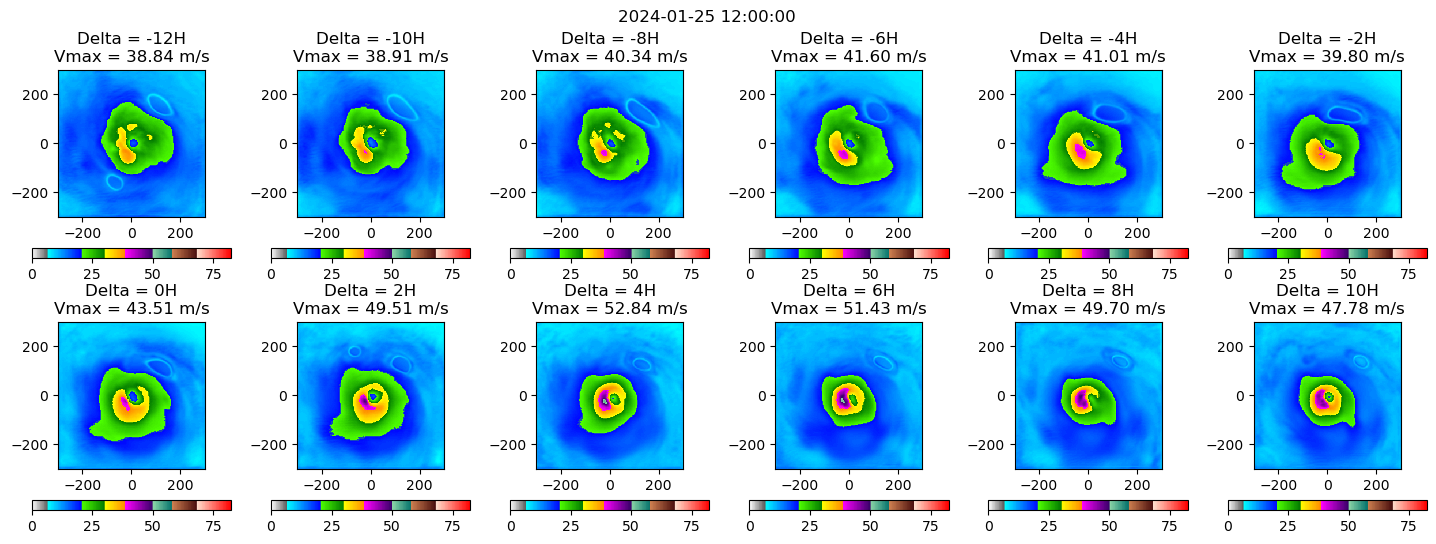

In [3]:
from datetime import datetime, timedelta 
from collections import defaultdict

# Dictionnaire contenant, pour chaque instant, toutes les prédictions
# disponibles issues des différentes séquences temporelles.
preds_by_time = defaultdict(list)

for i in range(preds_overlap.shape[0]):
    for c in range(12):
        preds_by_time[times_overlap[i, c]].append(
            preds_overlap[i, c]
        )

# Date et heure pour lesquelles les différentes prédictions
# seront comparées.
t = datetime(2024, 1, 25, 12)

# Création d'une grille de 12 cartes (2 lignes × 6 colonnes).
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

# Liste permettant de conserver les cartes correspondant
# aux différents décalages temporels (Delta).
cartes_deltas = []

for i in range(2):
    for j in range(6):

        # Indice de la prédiction dans la liste associée à l'instant t.
        idx = i * 6 + j

        # Récupération de la carte correspondant au décalage temporel.
        cartes_deltas.append(preds_by_time[t][idx])

        # Affichage de la carte de vent prédite.
        plot_sar(
            preds_by_time[t][idx],
            fig=fig,
            ax=axes[i, j]
        )

        # Ajout du décalage temporel et de la vitesse maximale
        # du vent dans le titre de chaque carte.
        axes[i, j].set_title(
            f"Delta = {np.arange(-12, 14, 2)[idx]}H\n"
            f"Vmax = {np.nanmax(preds_by_time[t][idx]):.2f} m/s"
        )
plt.suptitle(f"{str(t)}")

/tmp/ipykernel_2924467/718379276.py:42: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 500x500 with 0 Axes> which fig.colorbar is called on.
  fig.colorbar(im, ax=ax, orientation="horizontal")


Text(0.5, 1.0, 'Reconstruction moyenne : 2024-01-25 12:00:00\nVmax = 43.23 m/s\nIBTrACS Vmax = 41 m/s')

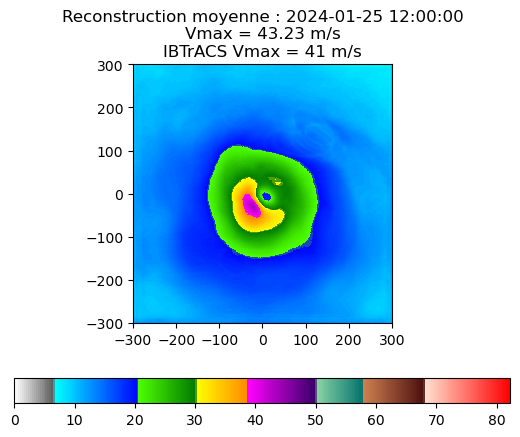

In [4]:
# Calcul de la moyenne des cartes prédites pour les différents
# décalages temporels associés à l'instant t.
carte_moyenne = np.array(cartes_deltas).mean(axis=0)

# Affichage de la carte de vent obtenue en moyennant
# l'ensemble des prédictions disponibles.
plot_sar(
    carte_moyenne,
    fig=plt.Figure(figsize=(5, 5))
)
plt.title(
    f"Reconstruction moyenne : {str(t)}\n"
    f"Vmax = {np.nanmax(carte_moyenne):.2f} m/s\n"
    f"IBTrACS Vmax = 41 m/s"
)

In [5]:
# Dictionnaire permettant de regrouper, pour chaque instant temporel,
# toutes les prédictions disponibles ainsi que les informations
# relatives à leur séquence d'origine.
preds_by_time_info = defaultdict(list)

for i in range(preds_overlap.shape[0]):
    
    # Début et fin de la fenêtre temporelle de la séquence courante.
    window_start = times_overlap[i, 0]
    window_end = times_overlap[i, -1]

    for c in range(12):

        # Instant temporel correspondant au canal courant.
        t = times_overlap[i, c]

        # Stockage de la prédiction et des informations permettant
        # d'identifier précisément sa provenance.
        preds_by_time_info[t].append({
            "prediction": preds_overlap[i, c],
            "channel": c,
            "sequence": i,
            "window_start": window_start,
            "window_end": window_end,
        })

In [6]:
import pandas as pd
# Heure de début des séquences temporelles que l'on souhaite affiché.
START_HOUR = 0

# Période temporelle étudiée.
start_date = pd.Timestamp("2024-01-14 00:00:00")
end_date = pd.Timestamp("2024-01-29 22:00:00")

# Récupération de la trajectoire et des vitesses de vent de référence
# associées au cyclone Angrek.
anggrek = pd.read_csv(
    "https://cyclobs.ifremer.fr/app/api/track?"
    "sid=sh062024&freq=120&source=atcf&"
    "min_date=2024-01-13&max_date=2024-01-31"
)

selected_predictions = []

# Parcours de tous les instants disponibles dans le dictionnaire
# contenant les prédictions et leurs informations associées.
for t in sorted(preds_by_time_info):

    t_pd = pd.Timestamp(t)

    # Conservation uniquement des prédictions comprises
    # dans la période temporelle étudiée.
    if not (start_date <= t_pd <= end_date):
        continue

    # Recherche des prédictions provenant uniquement
    # des fenêtres temporelles commençant à START_HOUR.
    candidates = [
        item
        for item in preds_by_time_info[t]
        if item["window_start"].hour == START_HOUR
    ]

    # Aucun candidat disponible pour cet instant.
    if len(candidates) == 0:
        continue

    # Vérification de la présence éventuelle de plusieurs candidats.
    if len(candidates) > 1:
        print(
            "Attention:",
            t,
            "possède",
            len(candidates),
            "candidats"
        )

    # Sélection du premier candidat disponible.
    item = candidates[0]

    selected_predictions.append({
        "date": t_pd,
        "prediction": item["prediction"],
        "channel": item["channel"],
        "window_start": item["window_start"],
    })

rows = []

for item in selected_predictions:

    # Copie du champ de vent prédit.
    wind_field = item["prediction"].copy()

    # Sélection uniquement des valeurs valides.
    finite_values = wind_field[np.isfinite(wind_field)]

    # Cas où aucune valeur valide n'est disponible.
    if finite_values.size == 0:

        vmax_raw = np.nan

    else:

        # Vitesse maximale brute présente dans le champ de vent.
        vmax_raw = float(
            np.nanmax(wind_field)
        )

    # Stockage des résultats associés à chaque instant.
    rows.append({
        "date": item["date"],
        "vmax_raw": vmax_raw,
        "channel": item["channel"],
        "window_start": item["window_start"],
    })


anggrek_plot = anggrek.copy()

# Conversion des dates au format datetime.
anggrek_plot["date"] = pd.to_datetime(
    anggrek_plot["date"],
    errors="coerce",
    utc=True,
)

# Suppression du fuseau horaire pour faciliter
# la comparaison avec les dates des prédictions.
anggrek_plot["date"] = (
    anggrek_plot["date"]
    .dt.tz_convert(None)
)

# Conversion de la vitesse du vent en valeurs numériques.
anggrek_plot["wind_speed (m/s)"] = pd.to_numeric(
    anggrek_plot["wind_speed (m/s)"],
    errors="coerce",
)

# Suppression des lignes contenant des dates
# ou des vitesses de vent invalides.
anggrek_plot = anggrek_plot.dropna(
    subset=[
        "date",
        "wind_speed (m/s)",
    ]
)

# Conservation uniquement de la période étudiée.
anggrek_plot = anggrek_plot[
    (anggrek_plot["date"] >= start_date)
    &
    (anggrek_plot["date"] <= end_date)
].copy()

# Si plusieurs observations sont disponibles au même instant,
# leur vitesse de vent moyenne est utilisée comme référence.
anggrek_by_date = (
    anggrek_plot
    .groupby("date", as_index=False)
    .agg({
        "wind_speed (m/s)": "mean"
    })
    .sort_values("date")
)

# Création d'un DataFrame contenant les Vmax prédites.
comparison_df = pd.DataFrame(rows)

# Association des prédictions avec les valeurs de référence
# correspondant aux mêmes dates.
comparison_df = comparison_df.merge(
    anggrek_by_date.rename(
        columns={
            "wind_speed (m/s)": "ibtracs_vmax"
        }
    ),
    on="date",
    how="left",
)

# Métriques calculées à partir de la Vmax brute.
metrics_raw = compute_metrics(
    comparison_df["ibtracs_vmax"],
    comparison_df["vmax_raw"],
)


In [7]:
import matplotlib.dates as mdates

# Nombre de canaux temporels contenus dans chaque séquence.
N_CHANNELS = 12
# Pas temporel entre deux canaux consécutifs, en heures.
STEP_HOURS = 2

# Canal considéré comme référence temporelle.
#
# Avec CENTER_CHANNEL = 6 :
#   channel 6 -> delta_t =  0 h
#   channel 7 -> delta_t = +2 h
#   channel 8 -> delta_t = +4 h
#   channel 5 -> delta_t = -2 h
#   channel 4 -> delta_t = -4 h
CENTER_CHANNEL = 6

# Dictionnaire regroupant, pour chaque instant prédit,
# toutes les prédictions disponibles ainsi que leurs informations
# temporelles et leur séquence d'origine.
preds_by_time_info = defaultdict(list)

for i in range(preds_overlap.shape[0]):

    # Début et fin de la fenêtre temporelle associée
    # à la séquence courante.
    window_start = pd.Timestamp(times_overlap[i, 0])
    window_end = pd.Timestamp(times_overlap[i, -1])

    for c in range(N_CHANNELS):

        # Instant réellement associé au canal courant.
        target_time = pd.Timestamp(times_overlap[i, c])

        # Calcul du décalage temporel du canal par rapport
        # au canal central de référence.
        delta_t = STEP_HOURS * (c - CENTER_CHANNEL)

        # Temps théorique attendu à partir du début de la fenêtre.
        expected_time = (
            window_start
            + pd.Timedelta(hours=STEP_HOURS * c)
        )

        # Vérification que le temps enregistré dans times_overlap
        # correspond bien au temps théorique attendu.
        if target_time != expected_time:
            raise ValueError(
                "\nIncohérence temporelle détectée :"
                f"\nsequence       = {i}"
                f"\nchannel        = {c}"
                f"\nwindow_start   = {window_start}"
                f"\ntarget_time    = {target_time}"
                f"\nexpected_time  = {expected_time}"
            )

        # Enregistrement de la prédiction ainsi que de toutes
        # les informations permettant d'identifier sa provenance
        # et son décalage temporel.
        preds_by_time_info[target_time].append({
            "prediction": preds_overlap[i, c],
            "channel": c,
            "delta_t": delta_t,
            "sequence": i,
            "target_time": target_time,
            "window_start": window_start,
            "window_end": window_end,
        })


In [8]:
def build_comparison_df_for_delta(
    delta_t,
    preds_by_time_info,
    anggrek,
    start_date,
    end_date,
):
    # Le décalage temporel demandé doit être compatible
    # avec le pas temporel entre les différents channels.
    if delta_t % STEP_HOURS != 0:
        raise ValueError(
            f"delta_t doit être un multiple de {STEP_HOURS} heures."
        )

    # Conversion du delta temporel demandé vers
    # le channel correspondant.
    target_channel = (
        CENTER_CHANNEL
        + delta_t // STEP_HOURS
    )

    # Vérification que le channel correspondant existe bien.
    if not (0 <= target_channel < N_CHANNELS):

        min_delta = STEP_HOURS * (0 - CENTER_CHANNEL)
        max_delta = STEP_HOURS * (
            (N_CHANNELS - 1) - CENTER_CHANNEL
        )

        raise ValueError(
            f"delta_t={delta_t:+d} h impossible.\n"
            f"Avec {N_CHANNELS} channels et CENTER_CHANNEL="
            f"{CENTER_CHANNEL}, les deltas possibles sont "
            f"de {min_delta:+d} h à {max_delta:+d} h."
        )


    selected_predictions = []

    for t in sorted(preds_by_time_info):

        t_pd = pd.Timestamp(t)

        # Conservation uniquement des dates comprises
        # dans la période temporelle étudiée.
        if not (start_date <= t_pd <= end_date):
            continue

        # Recherche de la prédiction correspondant exactement
        # au delta temporel demandé.
        candidates = [
            item
            for item in preds_by_time_info[t]
            if item["delta_t"] == delta_t
        ]

        # Aucun candidat disponible pour cet instant.
        if len(candidates) == 0:
            continue

        # Une seule prédiction doit correspondre
        # à un instant et un delta donnés.
        if len(candidates) > 1:
            raise ValueError(
                f"{len(candidates)} prédictions trouvées pour "
                f"{t_pd} avec Δt={delta_t:+d} h."
            )

        item = candidates[0]

        # Le channel enregistré doit correspondre
        # au channel théorique associé au delta demandé.
        if item["channel"] != target_channel:
            raise ValueError(
                f"Incohérence channel/delta à {t_pd}: "
                f"delta={delta_t:+d} h, "
                f"channel trouvé={item['channel']}, "
                f"channel attendu={target_channel}"
            )

        # Reconstruction du temps cible à partir du début
        # de la fenêtre et du numéro du channel.
        expected_target_time = (
            item["window_start"]
            + pd.Timedelta(
                hours=STEP_HOURS * item["channel"]
            )
        )

        # Vérification que le temps reconstruit correspond
        # bien à l'instant réellement associé à la prédiction.
        if expected_target_time != t_pd:
            raise ValueError(
                f"Incohérence temporelle à {t_pd}: "
                f"window_start={item['window_start']}, "
                f"channel={item['channel']}, "
                f"donne {expected_target_time}."
            )

        # Stockage de la prédiction sélectionnée
        # avec ses informations temporelles.
        selected_predictions.append({
            "date": t_pd,
            "prediction": item["prediction"],
            "channel": item["channel"],
            "delta_t": item["delta_t"],
            "sequence": item["sequence"],
            "window_start": item["window_start"],
            "window_end": item["window_end"],
        })

    rows = []

    for item in selected_predictions:

        wind_field = item["prediction"]

        # Conservation uniquement des valeurs valides du champ.
        finite_values = wind_field[
            np.isfinite(wind_field)
        ]

        # Cas où aucune valeur exploitable n'est disponible.
        if finite_values.size == 0:

            vmax_raw = np.nan

        else:
            # Vitesse maximale brute du champ prédit.
            vmax_raw = float(
                np.nanmax(wind_field)
            )

        # Stockage des Vmax et des métadonnées correspondantes.
        rows.append({
            "date": item["date"],
            "vmax_raw": vmax_raw,
            "channel": item["channel"],
            "delta_t": item["delta_t"],
            "sequence": item["sequence"],
            "window_start": item["window_start"],
            "window_end": item["window_end"],
        })

    comparison_df = pd.DataFrame(rows)
    anggrek_plot = anggrek.copy()

    # Conversion des dates au format datetime.
    anggrek_plot["date"] = pd.to_datetime(
        anggrek_plot["date"],
        errors="coerce",
        utc=True,
    )

    # Suppression du fuseau horaire pour permettre
    # la comparaison avec les dates des prédictions.
    anggrek_plot["date"] = (
        anggrek_plot["date"]
        .dt.tz_convert(None)
    )

    # Conversion des vitesses de vent en valeurs numériques.
    anggrek_plot["wind_speed (m/s)"] = pd.to_numeric(
        anggrek_plot["wind_speed (m/s)"],
        errors="coerce",
    )

    # Suppression des observations invalides.
    anggrek_plot = anggrek_plot.dropna(
        subset=[
            "date",
            "wind_speed (m/s)",
        ]
    )

    # Sélection de la période temporelle étudiée.
    anggrek_plot = anggrek_plot[
        (anggrek_plot["date"] >= start_date)
        &
        (anggrek_plot["date"] <= end_date)
    ].copy()

    # Si plusieurs valeurs de référence existent à la même date,
    # leur moyenne est utilisée.
    anggrek_by_date = (
        anggrek_plot
        .groupby("date", as_index=False)
        .agg({
            "wind_speed (m/s)": "mean"
        })
        .sort_values("date")
    )

    comparison_df = comparison_df.merge(
        anggrek_by_date.rename(
            columns={
                "wind_speed (m/s)": "ibtracs_vmax"
            }
        ),
        on="date",
        how="left",
    )

    # Comparaison entre la Vmax brute prédite
    # et la Vmax de référence IBTrACS.
    metrics_raw = compute_metrics(
        comparison_df["ibtracs_vmax"],
        comparison_df["vmax_raw"],
    )

    return comparison_df, metrics_raw

In [9]:
def build_comparison_df_mean_delta(
    preds_by_time_info,
    anggrek,
    start_date,
    end_date,
    deltas_to_use=None,
):
    """
    Construit une reconstruction moyenne pixel par pixel à partir
    des prédictions correspondant à une même heure cible.

    Seuls les décalages temporels spécifiés dans `deltas_to_use`
    sont utilisés.

    Exemples :
        deltas_to_use=[-2, 0, 2]
        deltas_to_use=[-6, -4, -2, 0, 2, 4, 6]
        deltas_to_use=[0, 2, 4, 6]

    Si deltas_to_use=None, tous les deltas disponibles sont utilisés.
    """
    if deltas_to_use is not None:
        # Conversion en entiers et suppression des doublons.
        deltas_to_use = sorted(
            set(int(delta) for delta in deltas_to_use)
        )
        for delta in deltas_to_use:

            # Chaque delta doit respecter le pas temporel
            # défini entre deux channels.
            if delta % STEP_HOURS != 0:
                raise ValueError(
                    f"Delta invalide : {delta} h. "
                    f"Tous les deltas doivent être des multiples "
                    f"de {STEP_HOURS} h."
                )

            # Détermination du channel associé au delta.
            channel = (
                CENTER_CHANNEL
                + delta // STEP_HOURS
            )

            # Vérification que le channel existe.
            if not (0 <= channel < N_CHANNELS):
                raise ValueError(
                    f"Delta {delta:+d} h impossible : "
                    f"il correspondrait au channel {channel}."
                )

    rows = []

    for t in sorted(preds_by_time_info):

        t_pd = pd.Timestamp(t)

        # Conservation uniquement de la période étudiée.
        if not (start_date <= t_pd <= end_date):
            continue

        # Toutes les prédictions disponibles pour l'heure cible.
        candidates = preds_by_time_info[t]

        if len(candidates) == 0:
            continue

        if deltas_to_use is not None:

            candidates = [
                item
                for item in candidates
                if item["delta_t"] in deltas_to_use
            ]

        if len(candidates) == 0:
            continue

        valid_candidates = []

        for item in candidates:

            # Reconstruction de l'heure théorique associée
            # au début de la fenêtre et au channel.
            expected_time = (
                pd.Timestamp(item["window_start"])
                + pd.Timedelta(
                    hours=STEP_HOURS * item["channel"]
                )
            )

            if expected_time != t_pd:
                raise ValueError(
                    f"Incohérence temporelle pour {t_pd}\n"
                    f"sequence = {item['sequence']}\n"
                    f"channel = {item['channel']}\n"
                    f"delta = {item['delta_t']} h\n"
                    f"window_start = {item['window_start']}\n"
                    f"expected_time = {expected_time}"
                )

            valid_candidates.append(item)

        deltas_present = [
            item["delta_t"]
            for item in valid_candidates
        ]

        # Une même heure cible ne doit pas contenir deux
        # prédictions associées au même delta.
        if len(deltas_present) != len(set(deltas_present)):
            raise ValueError(
                f"Deltas dupliqués pour {t_pd}: "
                f"{deltas_present}"
            )

        # Empilement des cartes :
        # shape = (N_delta, H, W)
        predictions = np.stack(
            [
                item["prediction"]
                for item in valid_candidates
            ],
            axis=0,
        )

        # Moyenne suivant la dimension des deltas.
        # Résultat : une seule carte 2D (H, W).
        mean_prediction = np.nanmean(
            predictions,
            axis=0,
        )

        H, W = mean_prediction.shape

        crop_size = 128

        y0 = H // 2 - crop_size // 2
        y1 = H // 2 + crop_size // 2

        x0 = W // 2 - crop_size // 2
        x1 = W // 2 + crop_size // 2

        mean_prediction_center = mean_prediction[
            y0:y1,
            x0:x1,
        ]

        finite_values = mean_prediction[
            np.isfinite(mean_prediction)
        ]

        if finite_values.size == 0:

            vmax_raw = np.nan

        else:

            # Maximum brut sur toute la carte.
            vmax_raw = float(
                np.nanmax(mean_prediction)
            )

        finite_center = mean_prediction_center[
            np.isfinite(mean_prediction_center)
        ]

        if finite_center.size == 0:

            vmax_center = np.nan
            vmax_center_robust = np.nan

        else:

            # Maximum brut dans la région centrale.
            vmax_center = float(
                np.nanmax(mean_prediction_center)
            )

        rows.append({
            "date": t_pd,

            # Vmax sur la carte entière.
            "vmax_raw": vmax_raw,

            # Vmax sur le crop central.
            "vmax_center": vmax_center,

            # Informations sur la reconstruction.
            "n_predictions": len(valid_candidates),
            "deltas_used": tuple(
                sorted(deltas_present)
            ),
        })

    comparison_df = pd.DataFrame(rows)

    anggrek_plot = anggrek.copy()

    # Conversion des dates.
    anggrek_plot["date"] = pd.to_datetime(
        anggrek_plot["date"],
        errors="coerce",
        utc=True,
    )

    anggrek_plot["date"] = (
        anggrek_plot["date"]
        .dt.tz_convert(None)
    )

    # Conversion des vitesses de vent.
    anggrek_plot["wind_speed (m/s)"] = pd.to_numeric(
        anggrek_plot["wind_speed (m/s)"],
        errors="coerce",
    )

    # Suppression des observations invalides.
    anggrek_plot = anggrek_plot.dropna(
        subset=[
            "date",
            "wind_speed (m/s)",
        ]
    )

    # Sélection de la période étudiée.
    anggrek_plot = anggrek_plot[
        (anggrek_plot["date"] >= start_date)
        &
        (anggrek_plot["date"] <= end_date)
    ].copy()

    # Moyenne si plusieurs valeurs sont présentes à la même date.
    anggrek_by_date = (
        anggrek_plot
        .groupby("date", as_index=False)
        .agg({
            "wind_speed (m/s)": "mean"
        })
        .sort_values("date")
    )

    satcon_plots = pd.read_csv(
        "https://cyclobs.ifremer.fr/app/api/track?"
        "sid=sh062024&freq=120&source=satcon"
    )

    # Conversion des dates.
    satcon_plots["date"] = pd.to_datetime(
        satcon_plots["date"],
        errors="coerce",
        utc=True,
    )

    satcon_plots["date"] = (
        satcon_plots["date"]
        .dt.tz_convert(None)
    )

    # Conversion des vitesses de vent.
    satcon_plots["wind_speed (m/s)"] = pd.to_numeric(
        satcon_plots["wind_speed (m/s)"],
        errors="coerce",
    )

    # Suppression des observations invalides.
    satcon_plots = satcon_plots.dropna(
        subset=[
            "date",
            "wind_speed (m/s)",
        ]
    )

    # Sélection de la période étudiée.
    satcon_plots = satcon_plots[
        (satcon_plots["date"] >= start_date)
        &
        (satcon_plots["date"] <= end_date)
    ].copy()

    # Moyenne si plusieurs observations SATCON
    # sont disponibles à la même date.
    satcon_by_date = (
        satcon_plots
        .groupby(
            "date",
            as_index=False,
        )
        .agg({
            "wind_speed (m/s)": "mean"
        })
        .rename(
            columns={
                "wind_speed (m/s)": "satcon_vmax"
            }
        )
        .sort_values("date")
    )
    era5_plot = pd.read_csv(
        "/scale/user/mtannaou/alternance/src/IR_to_SAR/"
        "ML_IR_SAR/csv_data/anggrek_coloc_sar_ir.csv"
    )

    # Conversion des dates.
    era5_plot["date"] = pd.to_datetime(
        era5_plot["date"],
        errors="coerce",
        utc=True,
    )

    era5_plot["date"] = (
        era5_plot["date"]
        .dt.tz_convert(None)
    )

    # Conversion de Vmax ERA5.
    era5_plot["era5_vmax"] = pd.to_numeric(
        era5_plot["era5_vmax"],
        errors="coerce",
    )

    # Suppression des valeurs invalides.
    era5_plot = era5_plot.dropna(
        subset=[
            "date",
            "era5_vmax",
        ]
    )

    # Sélection de la période étudiée.
    era5_plot = era5_plot[
        (era5_plot["date"] >= start_date)
        &
        (era5_plot["date"] <= end_date)
    ].copy()

    # Moyenne si plusieurs valeurs ERA5 existent
    # pour une même date.
    era5_by_date = (
        era5_plot
        .groupby(
            "date",
            as_index=False,
        )
        .agg({
            "era5_vmax": "mean"
        })
        .sort_values("date")
    )

    # Rééchantillonnage des données ERA5 avec un pas de 2 heures.
    era5_2h = (
        era5_by_date
        .set_index("date")
        .resample("2h")
        .mean()
    )

    # Interpolation temporelle des valeurs manquantes.
    era5_2h["era5_vmax"] = (
        era5_2h["era5_vmax"]
        .interpolate(method="time")
    )

    era5_2h = era5_2h.reset_index()

    comparison_df = comparison_df.merge(
        anggrek_by_date.rename(
            columns={
                "wind_speed (m/s)": "ibtracs_vmax"
            }
        ),
        on="date",
        how="left",
    )

    comparison_df = comparison_df.sort_values("date")
    satcon_by_date = satcon_by_date.sort_values("date")

    # Association avec la mesure SATCON la plus proche,
    # avec une tolérance maximale d'une heure.
    comparison_df = pd.merge_asof(
        comparison_df,
        satcon_by_date,
        on="date",
        direction="nearest",
        tolerance=pd.Timedelta("1h"),
    )
    comparison_df = comparison_df.sort_values("date")

    # Association avec la valeur ERA5 la plus proche,
    # avec une tolérance maximale d'une heure.
    comparison_df = pd.merge_asof(
        comparison_df,
        era5_2h.sort_values("date"),
        on="date",
        direction="nearest",
        tolerance=pd.Timedelta("1h"),
    )

    # Métriques entre IBTrACS et la Vmax calculée
    # sur l'ensemble de la carte reconstruite.
    metrics = compute_metrics(
        comparison_df["ibtracs_vmax"],
        comparison_df["vmax_raw"],
    )

    # Métriques entre IBTrACS et la Vmax calculée
    # uniquement dans le crop central 128 × 128.
    metrics_center = compute_metrics(
        comparison_df["ibtracs_vmax"],
        comparison_df["vmax_center"],
    )
    return comparison_df, metrics, metrics_center

In [10]:
def plot_delta(
    delta_t,
    deltas_to_use=None,
    enveloppe=False,
    ax=None,
    start_date=None,
    end_date=None,
):
    # Dates utilisées par défaut si aucune période
    # n'est fournie lors de l'appel de la fonction.
    if start_date is None:
        start_date = pd.Timestamp("2024-01-14 00:00:00")
    else:
        start_date = pd.Timestamp(start_date)

    if end_date is None:
        end_date = pd.Timestamp("2024-01-29 22:00:00")
    else:
        end_date = pd.Timestamp(end_date)

    # Si aucun axe n'est fourni, création d'une nouvelle figure.
    if ax is None:

        fig, ax = plt.subplots(
            figsize=(18, 7)
        )

        standalone = True

    else:

        # Si un axe existe déjà, la fonction trace directement dessus.
        standalone = False

    if delta_t == "mean":

        # Construction de la reconstruction moyenne pixel par pixel
        # à partir des deltas sélectionnés.
        comparison_df, metrics, _ = (
            build_comparison_df_mean_delta(
                preds_by_time_info=preds_by_time_info,
                anggrek=anggrek,
                start_date=start_date,
                end_date=end_date,
                deltas_to_use=deltas_to_use,
            )
        )

        ax.plot(
            comparison_df["date"],
            comparison_df["ibtracs_vmax"],
            linewidth=2.5,
            label="IBTrACS",
            zorder=5,
            color="black",
        )
 
        # vmax_raw correspond au maximum calculé APRÈS
        # la moyenne pixel par pixel des cartes 2D.
        ax.plot(
            comparison_df["date"],
            comparison_df["vmax_raw"],
            linewidth=1.8,
            alpha=0.90,
            label="Reconstruction Moyenne",
            zorder=4,
            color="green",
        )

        ax.plot(
            comparison_df["date"],
            comparison_df["satcon_vmax"],
            linewidth=1.8,
            alpha=0.90,
            label="SATCON",
            zorder=4,
            color="blue",
        )

        ax.plot(
            comparison_df["date"],
            comparison_df["era5_vmax"],
            linewidth=1.8,
            alpha=0.90,
            label="ERA5",
            zorder=4,
            color="orange",
        )

        # L'enveloppe représente, pour chaque date :
        #
        #   borne inférieure = min(Vmax des deltas)
        #   borne supérieure = max(Vmax des deltas)
        #
        # Elle permet donc de visualiser la dispersion des Vmax
        # obtenues avec les différentes reconstructions.
        if enveloppe:

            envelope_dates = []
            envelope_min = []
            envelope_max = []

            # Parcours de toutes les dates présentes
            # dans le DataFrame de comparaison.
            for t in comparison_df["date"]:

                t_pd = pd.Timestamp(t)

                # Récupération de toutes les prédictions disponibles
                # pour cette heure cible.
                candidates = preds_by_time_info.get(
                    t_pd,
                    [],
                )

                # Conservation uniquement des deltas utilisés
                # pour construire la reconstruction moyenne.
                if deltas_to_use is not None:

                    candidates = [
                        item
                        for item in candidates
                        if item["delta_t"] in deltas_to_use
                    ]

                if len(candidates) == 0:
                    continue

                vmax_individual = []

                for item in candidates:

                    prediction_2d = item["prediction"]

                    # Vérification de la présence de valeurs valides.
                    finite_values = prediction_2d[
                        np.isfinite(prediction_2d)
                    ]

                    if finite_values.size == 0:
                        continue

                    # Maximum de la reconstruction individuelle.
                    vmax_delta = float(
                        np.nanmax(prediction_2d)
                    )

                    vmax_individual.append(
                        vmax_delta
                    )

                # Aucun champ valide disponible.
                if len(vmax_individual) == 0:
                    continue

                envelope_dates.append(
                    t_pd
                )

                envelope_min.append(
                    float(
                        np.min(vmax_individual)
                    )
                )

                envelope_max.append(
                    float(
                        np.max(vmax_individual)
                    )
                )

            ax.fill_between(
                envelope_dates,
                envelope_min,
                envelope_max,
                alpha=0.18,
                label="Δt envelope (min–max)",
                zorder=1,
            )

        if deltas_to_use is None:

            delta_text = "all available Δt"

        else:

            delta_text = ", ".join(
                f"{d:+d}h"
                for d in sorted(
                    set(deltas_to_use)
                )
            )

        if enveloppe:
            envelope_text = " | min–max envelope"
        else:
            envelope_text = ""

        ax.set_title(
            f"RMSE={metrics['rmse']:.2f} m/s | "
            f"MAE={metrics['mae']:.2f} m/s | "
            f"Bias={metrics['bias']:.2f} m/s",
            fontsize=11,
        )

    elif delta_t == 0:

        # Construction du DataFrame pour le canal central,
        # correspondant à un décalage temporel nul.
        comparison_df, metrics = (
            build_comparison_df_for_delta(
                delta_t=0,
                preds_by_time_info=preds_by_time_info,
                anggrek=anggrek,
                start_date=start_date,
                end_date=end_date,
            )
        )

        ax.plot(
            comparison_df["date"],
            comparison_df["ibtracs_vmax"],
            linewidth=2.5,
            label="IBTrACS",
            zorder=4,
        )

        ax.plot(
            comparison_df["date"],
            comparison_df["vmax_raw"],
            linewidth=1.8,
            alpha=0.85,
            label="Δt = 0 h",
            zorder=3,
        )

        ax.set_title(
            f"Δt = 0 h\n"
            f"RMSE={metrics['rmse']:.2f} | "
            f"MAE={metrics['mae']:.2f} | "
            f"Bias={metrics['bias']:.2f} m/s",
            fontsize=12,
        )

    else:

        # Utilisation de la valeur absolue du delta demandé.
        delta_abs = abs(
            int(delta_t)
        )

        if delta_abs % STEP_HOURS != 0:

            raise ValueError(
                f"delta_t doit être un multiple de "
                f"{STEP_HOURS} heures."
            )

        comparison_plus, metrics_plus = (
            build_comparison_df_for_delta(
                delta_t=+delta_abs,
                preds_by_time_info=preds_by_time_info,
                anggrek=anggrek,
                start_date=start_date,
                end_date=end_date,
            )
        )

        comparison_minus, metrics_minus = (
            build_comparison_df_for_delta(
                delta_t=-delta_abs,
                preds_by_time_info=preds_by_time_info,
                anggrek=anggrek,
                start_date=start_date,
                end_date=end_date,
            )
        )

        ax.plot(
            comparison_plus["date"],
            comparison_plus["ibtracs_vmax"],
            linewidth=2.5,
            label="IBTrACS",
            zorder=4,
        )

        ax.plot(
            comparison_plus["date"],
            comparison_plus["vmax_raw"],
            linewidth=1.7,
            alpha=0.85,
            label=f"Δt = +{delta_abs} h",
            zorder=3,
        )

        ax.plot(
            comparison_minus["date"],
            comparison_minus["vmax_raw"],
            linewidth=1.7,
            alpha=0.85,
            label=f"Δt = -{delta_abs} h",
            zorder=2,
        )

        ax.set_title(
            f"Δt = ±{delta_abs} h\n"
            f"+{delta_abs}h: "
            f"RMSE={metrics_plus['rmse']:.2f}, "
            f"MAE={metrics_plus['mae']:.2f}, "
            f"Bias={metrics_plus['bias']:.2f}\n"
            f"-{delta_abs}h: "
            f"RMSE={metrics_minus['rmse']:.2f}, "
            f"MAE={metrics_minus['mae']:.2f}, "
            f"Bias={metrics_minus['bias']:.2f}",
            fontsize=11,
        )

    ax.set_ylabel(
        "Vmax (m/s)",
        fontsize=11,
    )

    ax.set_xlabel(
        "Date",
        fontsize=11,
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.legend(
        fontsize=9,
    )

    # Affichage d'une date principale tous les deux jours.
    ax.xaxis.set_major_locator(
        mdates.DayLocator(
            interval=2
        )
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter(
            "%m-%d"
        )
    )

    # Graduations secondaires toutes les deux heures.
    ax.xaxis.set_minor_locator(
        mdates.HourLocator(
            byhour=list(
                range(0, 24, 2)
            )
        )
    )

    # Mise en forme des graduations.
    ax.tick_params(
        axis="x",
        rotation=40,
        labelsize=9,
    )

    ax.tick_params(
        axis="y",
        labelsize=9,
    )

    # Limitation de l'affichage à la période étudiée.
    ax.set_xlim(
        start_date,
        end_date,
    )

    # Affichage uniquement si la fonction a elle-même
    # créé la figure.
    if standalone:

        plt.tight_layout()
        plt.show()

    return ax

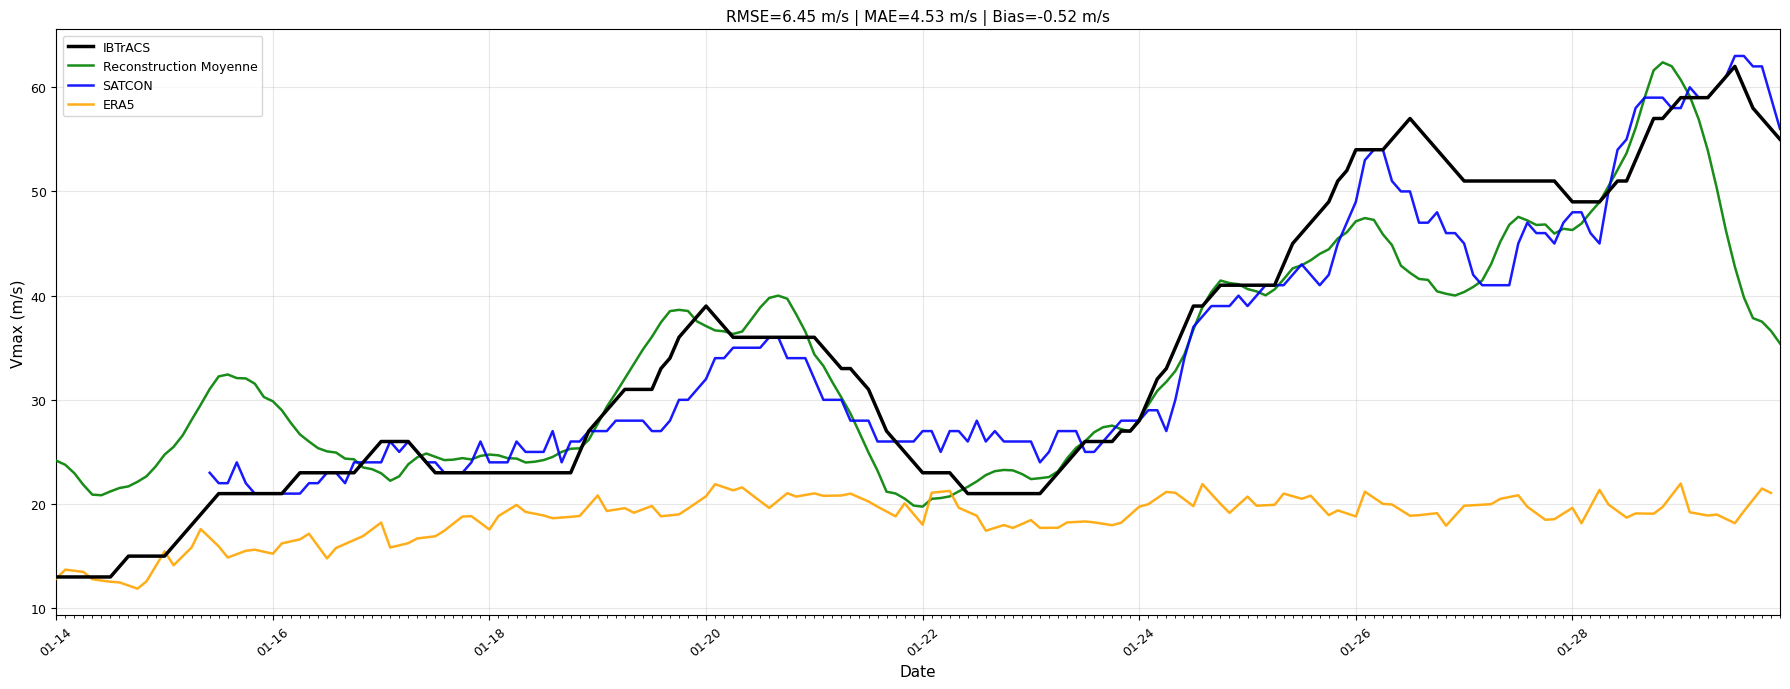

<Axes: title={'center': 'RMSE=6.45 m/s | MAE=4.53 m/s | Bias=-0.52 m/s'}, xlabel='Date', ylabel='Vmax (m/s)'>

In [11]:
plot_delta("mean",deltas_to_use = [-10,-8,-6,-4,-2,0,2,4,6,8,10])

## Metriques sur le set de test

In [13]:
import os; import pickle as pkl;import numpy as np;import torch;from tqdm import tqdm;from matplotlib import pyplot as plt
import src.IR_to_SAR.data_preparation.data_preprocessing as dataprep

os.chdir("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/training_results/temporal_mode/overlap_with_loss_voisins")
import torch.distributed as dist
os.environ["MASTER_ADDR"] = "localhost"
os.environ["MASTER_PORT"] = "0000"

dist.init_process_group(
    backend="gloo",
    rank=0,
    world_size=1
)
try:
    with open("model.pkl", "rb") as f:
        ddp_model = pkl.load(f)

    model = ddp_model.module if hasattr(ddp_model, "module") else ddp_model
    model.eval()
    print("Modèle chargé")
finally:
    if dist.is_initialized():
        dist.destroy_process_group()
device = model.device
print("Device:", device)

Modèle chargé
Device: cuda:2


In [30]:
## set de test
with open("sequence_data.pkl","rb") as f:
    data_test = pkl.load(f)
x_test = data_test["x_test"]  # °C
y_test = data_test["y_test"]  # m/s
with open("stats_normalisation.pkl","rb") as f:
    stats = pkl.load(f)
mean_x = stats["mean_x"]; std_x = stats["std_x"]
mean_sar = stats["mean_sar"]; std_sar = stats["std_sar"]
x_test_norm = (x_test - mean_x)/std_x
import torch ; from tqdm import tqdm
y_pred = np.zeros_like(y_test)
for i, x in enumerate(tqdm(x_test_norm, desc="Generatng prediction for test set ...",total=x_test_norm.shape[0])):
    x_torch = torch.from_numpy(x).float().unsqueeze(0).to(device)
    pred = model(x_torch, timestep=0).sample.squeeze().unsqueeze(1).detach().cpu().numpy()
    for c in range(pred.shape[0]):
        y_pred[i][c] = dataprep.annular_denormalization(pred[c], stats= {"mean":mean_sar, "std": std_sar})[0].squeeze()

y_pred.shape,y_test.shape, x_test.shape

(322, 12, 256, 256) (322, 12, 256, 256)


Generatng prediction for test set ...: 100%|██████████| 322/322 [05:34<00:00,  1.04s/it]


((322, 12, 256, 256), (322, 12, 256, 256), (322, 12, 256, 256))

In [31]:
ind = -1

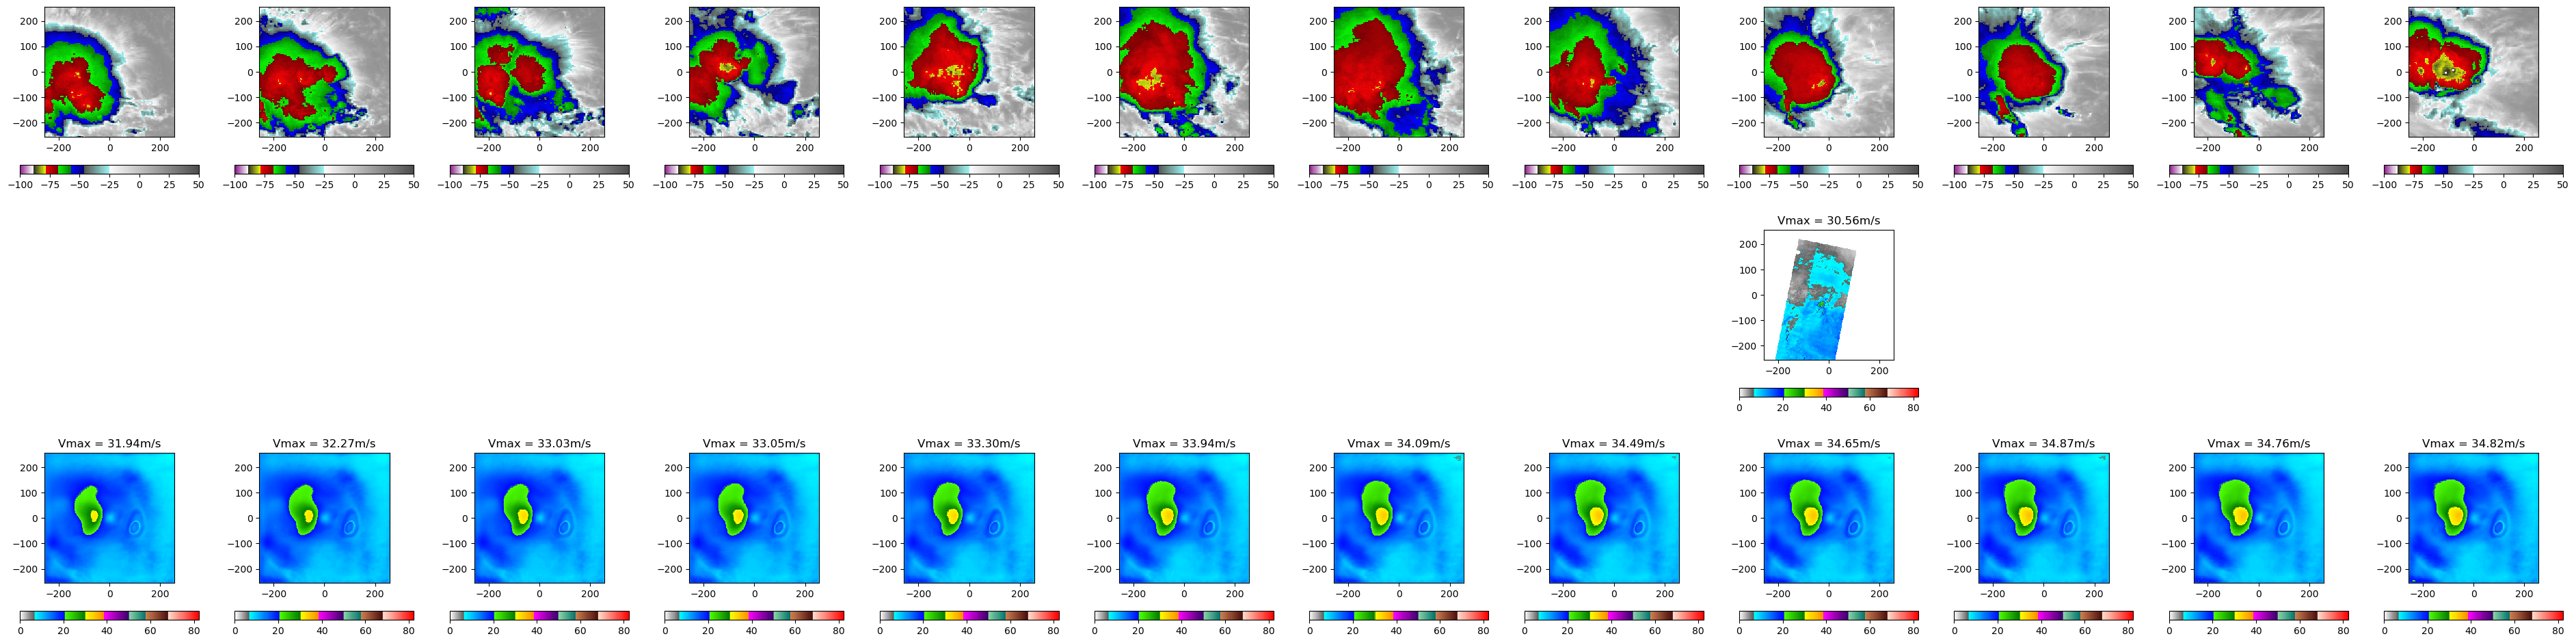

In [55]:
fig, axes = plt.subplots(3,12,figsize=(12*4,12))
ind += 1 

for c in range(12):
    plot_ir(x_test[ind][c], x_lim=x_test[ind][c].shape[-1], fig=fig,ax=axes[0,c])
    if np.nanmax(y_test[ind][c]) == 0.0:
        axes[1,c].axis("off")
    else : 
        plot_sar(y_test[ind][c], x_lim=y_test[ind][c].shape[-1], fig=fig, ax=axes[1,c]);axes[1,c].set_title(f"Vmax = {np.nanmax(y_test[ind][c]):.2f}m/s")
    plot_sar(y_pred[ind][c], x_lim = y_pred[ind][c].shape[-1], fig=fig, ax=axes[2,c]);axes[2,c].set_title(f"Vmax = {np.nanmax(y_pred[ind][c]):.2f}m/s")

In [57]:
import numpy as np
import hashlib

unique_sars = {}

for ind in range(len(y_test)):
    for c in range(y_test.shape[1]):

        sar = y_test[ind][c]
        vmax = np.nanmax(sar)

        # SAR invalide
        if vmax == 0.0:
            continue

        # Hash du SAR complet
        # nan_to_num permet d'avoir un hash stable en présence de NaN
        sar_clean = np.nan_to_num(
            sar,
            nan=-9999.0,
            posinf=9999.0,
            neginf=-9999.0
        )

        sar_hash = hashlib.md5(
            np.ascontiguousarray(sar_clean).tobytes()
        ).hexdigest()

        if sar_hash not in unique_sars:
            unique_sars[sar_hash] = {
                "ind": ind,
                "c": c,
                "vmax": vmax
            }


print("Nombre total de SAR valides avec overlap :", sum(
    np.nanmax(y_test[ind][c]) != 0
    for ind in range(len(y_test))
    for c in range(y_test.shape[1])
))

print("Nombre de SAR true uniques :", len(unique_sars))

Nombre total de SAR valides avec overlap : 348
Nombre de SAR true uniques : 33


In [58]:
import numpy as np
import hashlib

sar_predictions = {}

sar_hash_to_name = {}
sar_counter = 0

for ind in range(len(y_test)):
    for c in range(y_test.shape[1]):

        sar_true = y_test[ind][c]

        # SAR invalide
        if np.nanmax(sar_true) == 0.0:
            continue

        # Empreinte du SAR true
        sar_clean = np.nan_to_num(
            sar_true,
            nan=-9999.0,
            posinf=9999.0,
            neginf=-9999.0
        )

        sar_hash = hashlib.md5(
            np.ascontiguousarray(sar_clean).tobytes()
        ).hexdigest()

        # Nouveau SAR unique
        if sar_hash not in sar_hash_to_name:
            sar_name = f"sar_{sar_counter}"
            sar_hash_to_name[sar_hash] = sar_name

            sar_predictions[sar_name] = {
                "true": sar_true,
                "predictions": []
            }

            sar_counter += 1

        sar_name = sar_hash_to_name[sar_hash]

        # Ajouter toutes les prédictions possibles
        sar_predictions[sar_name]["predictions"].append({
            "sequence": ind,
            "canal": c,
            "prediction": y_pred[ind][c]
        })

In [61]:
import numpy as np
import matplotlib.pyplot as plt

vmax_target = []

# Méthode 1 :
# moyenne des cartes -> puis Vmax
vmax_mean_map = []

# Méthode 2 :
# Vmax de chaque carte -> puis moyenne
mean_vmax_maps = []


for sar_name, data in sar_predictions.items():

    # ==========================
    # Target réel
    # ==========================
    target = data["true"]

    vmax_true = np.nanmax(target)

    # ==========================
    # Toutes les prédictions
    # de ce même SAR
    # ==========================
    predictions = [
        p["prediction"]
        for p in data["predictions"]
    ]

    predictions = np.stack(predictions, axis=0)

    # ==========================
    # Méthode 1
    # Moyenne des cartes
    # puis Vmax
    # ==========================
    mean_map = np.nanmean(predictions, axis=0)

    vmax_from_mean_map = np.nanmax(mean_map)

    # ==========================
    # Méthode 2
    # Vmax de chaque prédiction
    # puis moyenne
    # ==========================
    vmax_each_prediction = np.nanmax(
        predictions,
        axis=tuple(range(1, predictions.ndim))
    )

    mean_of_vmax = np.nanmean(vmax_each_prediction)

    # ==========================
    # Stockage
    # ==========================
    vmax_target.append(vmax_true)
    vmax_mean_map.append(vmax_from_mean_map)
    mean_vmax_maps.append(mean_of_vmax)


# Conversion
vmax_target = np.asarray(vmax_target)
vmax_mean_map = np.asarray(vmax_mean_map)
mean_vmax_maps = np.asarray(mean_vmax_maps)

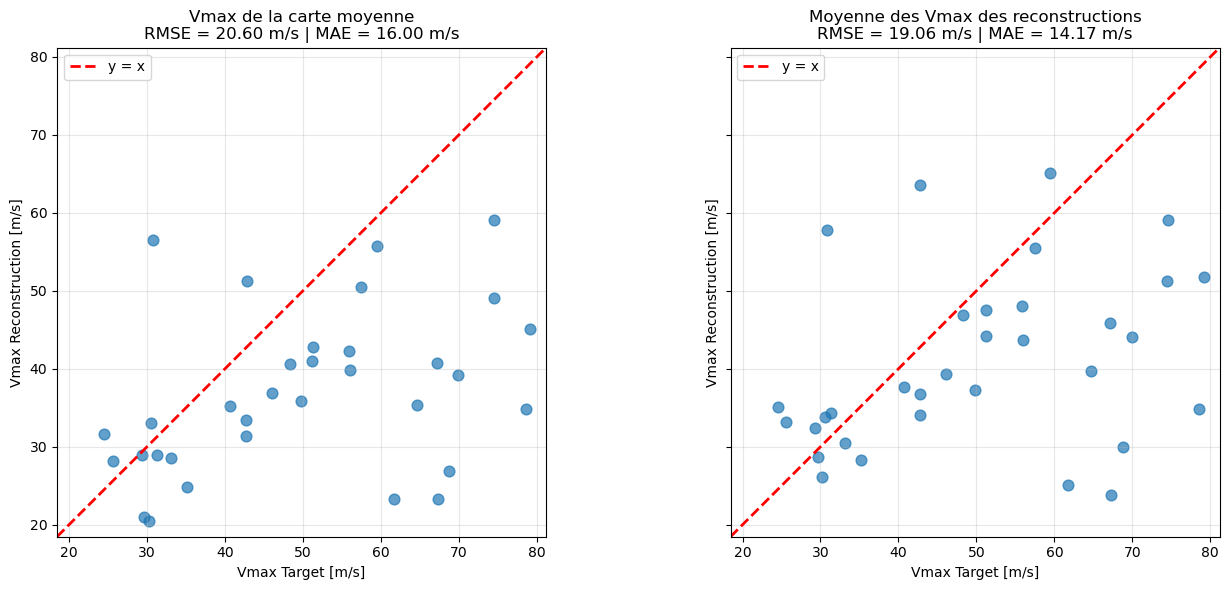

In [63]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharex=True,
    sharey=True
)

# Limites identiques pour les deux figures
vmin = np.nanmin([
    vmax_target.min(),
    vmax_mean_map.min(),
    mean_vmax_maps.min()
])

vmax = np.nanmax([
    vmax_target.max(),
    vmax_mean_map.max(),
    mean_vmax_maps.max()
])

# petite marge
margin = 2
vmin -= margin
vmax += margin


# ==================================================
# 1. Vmax de la carte moyenne
# ==================================================

axes[0].scatter(
    vmax_target,
    vmax_mean_map,
    s=60,
    alpha=0.7
)

axes[0].plot(
    [vmin, vmax],
    [vmin, vmax],
    "r--",
    linewidth=2,
    label="y = x"
)

axes[0].set_xlabel("Vmax Target [m/s]")
axes[0].set_ylabel("Vmax Reconstruction [m/s]")

axes[0].set_title(
    "Vmax de la carte moyenne\n"
    f"RMSE = {rmse_mean_map:.2f} m/s | "
    f"MAE = {mae_mean_map:.2f} m/s"
)

axes[0].grid(alpha=0.3)
axes[0].legend()


# ==================================================
# 2. Moyenne des Vmax
# ==================================================

axes[1].scatter(
    vmax_target,
    mean_vmax_maps,
    s=60,
    alpha=0.7
)

axes[1].plot(
    [vmin, vmax],
    [vmin, vmax],
    "r--",
    linewidth=2,
    label="y = x"
)

axes[1].set_xlabel("Vmax Target [m/s]")
axes[1].set_ylabel("Vmax Reconstruction [m/s]")

axes[1].set_title(
    "Moyenne des Vmax des reconstructions\n"
    f"RMSE = {rmse_mean_vmax:.2f} m/s | "
    f"MAE = {mae_mean_vmax:.2f} m/s"
)

axes[1].grid(alpha=0.3)
axes[1].legend()


# Même échelle
for ax in axes:
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

In [76]:
selected_canal = 6

In [77]:
import numpy as np
import matplotlib.pyplot as plt



vmax_target_canal = []
vmax_pred_canal = []
sar_names_canal = []

for sar_name, data in sar_predictions.items():

    # Vmax target réel
    vmax_true = np.nanmax(data["true"])

    # Chercher uniquement la prédiction correspondant au canal choisi
    pred_selected = None

    for p in data["predictions"]:
        if p["canal"] == selected_canal:
            pred_selected = p["prediction"]
            break

    # Ce SAR n'existe pas dans ce canal
    if pred_selected is None:
        continue

    vmax_p = np.nanmax(pred_selected)

    vmax_target_canal.append(vmax_true)
    vmax_pred_canal.append(vmax_p)
    sar_names_canal.append(sar_name)


vmax_target_canal = np.asarray(vmax_target_canal)
vmax_pred_canal = np.asarray(vmax_pred_canal)

print(f"Canal sélectionné : {selected_canal}")
print(f"Nombre de SAR utilisés : {len(vmax_target_canal)}")

Canal sélectionné : 6
Nombre de SAR utilisés : 29


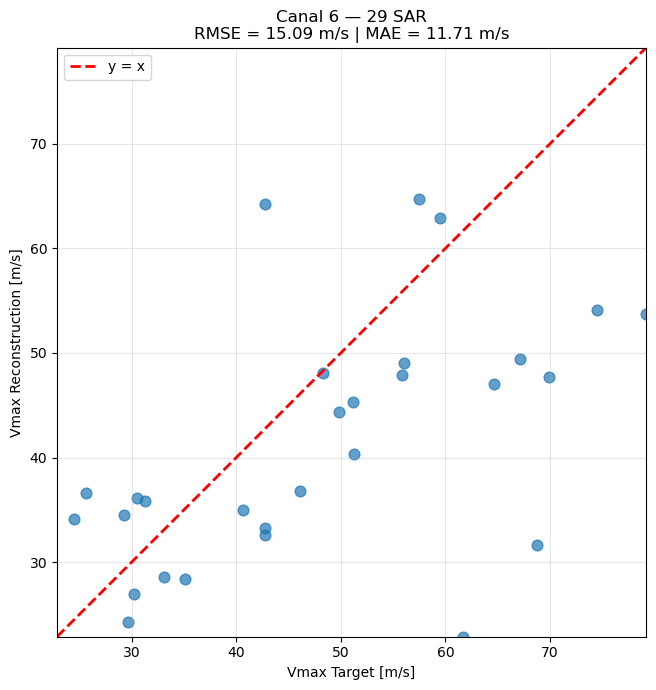

In [78]:
rmse = np.sqrt(
    np.mean((vmax_pred_canal - vmax_target_canal)**2)
)

mae = np.mean(
    np.abs(vmax_pred_canal - vmax_target_canal)
)
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    vmax_target_canal,
    vmax_pred_canal,
    s=60,
    alpha=0.7
)

vmin = min(
    np.nanmin(vmax_target_canal),
    np.nanmin(vmax_pred_canal)
)

vmax = max(
    np.nanmax(vmax_target_canal),
    np.nanmax(vmax_pred_canal)
)

ax.plot(
    [vmin, vmax],
    [vmin, vmax],
    "r--",
    linewidth=2,
    label="y = x"
)

ax.set_xlim(vmin, vmax)
ax.set_ylim(vmin, vmax)

ax.set_xlabel("Vmax Target [m/s]")
ax.set_ylabel("Vmax Reconstruction [m/s]")

ax.set_title(
    f"Canal {selected_canal} — {len(vmax_target_canal)} SAR\n"
    f"RMSE = {rmse:.2f} m/s | MAE = {mae:.2f} m/s"
)

ax.grid(alpha=0.3)
ax.legend()
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()